# Конфигурация окружения

## Нужные импорты

In [1]:
import logging
import re
import tempfile
import xml.etree.ElementTree as ET
import zipfile
from collections.abc import ValuesView
from copy import copy
from datetime import datetime

import NewareNDA
import pandas as pd
from beartype import beartype
import matplotlib.pyplot as plt
import battery_parser
import scipy as sp
import numpy as np
import seaborn as sns

In [2]:
logger = logging.getLogger('newarenda')

In [3]:
#Параметры окружения
xml_file = r'D:\!Science\Analysis\Electrochem\Test data\NDAX\With barcode and remarks\TestInfo.xml'
xml_settings = r'D:\!Science\Analysis\Electrochem\Test data\XML\simple.xml'
file_ndax = r'D:\!Science\Analysis\Electrochem\Test data\NDAX\With barcode and remarks.ndax'
sa_ndax = r'D:\!Science\Analysis\Electrochem\Test data\NDAX\104-1-8-SA28.ndax'
sa_ndax2 = r'D:\!Science\Analysis\Electrochem\Test data\NDAX\104-1-2-SA07.ndax'
directory = r'D:\!Science\Analysis\Electrochem\2024 Na-ion'
filtered_datapath = directory + '\\' + 'filtered_data.parquet'
parsed_datapath = directory + '\\' + 'parsed_data.parquet'

### Установка необходимых пакетов

In [ ]:
%pip install NewareNDA
%pip install ipykernel
%pip install pandas
%pip install lxml
%pip install zipfile
%pip install io
%pip install xml.etree.ElementTree
%pip install tempfile
%pip install logging
%pip install beartype
%pip install pyarrow fastparquet

## Проверка состояния окружения

In [ ]:
!python --version
%pip freeze

# Испытания

## Тесты

In [4]:
file = r"D:\\!Science\\Analysis\\Electrochem\\2024 Na-ion\\2025-01-10 target SoH cycling\\Данные 2025-05-30\\102-1-6-SB46.ndax"
imp = NewareNDA.read(file)

In [5]:
with tempfile.TemporaryDirectory() as tmpdir:
    zf = zipfile.PyZipFile(file)

    # Read version information
    version_info = zf.extract('TestInfo.xml', path=tmpdir)

    with open(version_info, 'r', encoding='gb2312') as f:
        text = f.read()
        config = ET.fromstring(text)



In [6]:
@beartype
def parse_et_to_dict(element: ET.Element, element_path: str = '') -> dict[str, dict[str, str]]:
    """Build a mapping from full XML paths to element attribute dicts.

    Parameters
    ----------
    element : xml.etree.ElementTree.Element
        Root element to traverse.
    element_path : str, optional
        Prefix path to start from. Used internally during recursion.

    Returns
    -------
    dict[str, dict[str, str]]
        Mapping: full absolute path (e.g., 'root/config/ZwjVersion') to the
        element's attribute dictionary. Paths are built from tag names.

    Notes
    -----
    - Attributes are recorded; element text is included as a tag element key.
    - The traversal is depth-first and includes every element exactly once.

    Examples
    --------
    >>> import xml.etree.ElementTree as ET
    >>> root = ET.fromstring('<a><b x="1"/><c y="2"/></a>')
    >>> parse_et_to_dict(root)
    {'a': {}, 'a/b': {'x': '1'}, 'a/c': {'y': '2'}}
    """
    elements = {}
    current_path = f"{element_path}/{element.tag}" if element_path else element.tag
    elements[current_path] = copy(element.attrib)

    if element.text and element.text.strip():
        if element.tag not in elements[current_path]:
            text_key = element.tag
        else:
            raise KeyError(f'Element tag "{element.tag}" already exist in attrib dict for "{current_path}".')
        elements[current_path].update({text_key: element.text})

    for child in element:
        elements.update(parse_et_to_dict(child, current_path))

    return elements

# all_elements = parse_et_to_dict(config)

In [7]:


def get_et_element(path: str) -> ET.Element:
    """
    Create element from XML file.
    Parameters
    ----------
    path:str
    Path to XML file.

    Returns
    -------
    ET.Element object
    Root element from XML file.
    """
    with open(path, 'r', encoding='gb2312') as f:
        text = f.read()
        element = ET.fromstring(text)
    return element


element = get_et_element(xml_file)
all_elements = parse_et_to_dict(element)
settings = parse_et_to_dict(get_et_element(xml_settings))

In [8]:
def search_dicts(dicts: dict[str, dict[str, str]], pattern: str, regex: bool = True, key: bool = True,
                 value: bool = True) -> dict:
    """
    Search dictionary for pattern matching.
    Parameters
    ----------
    dicts
    pattern
    regex
    key
    value

    Returns
    -------

    """
    result = {}

    if regex == False:
        for dictionary in dicts.values():
            if key:
                result.update({key: value for key, value in dictionary.items() if pattern in key})
            if value:
                result.update({key: value for key, value in dictionary.items() if pattern in value})
    else:
        pattern = re.compile(pattern)
        for dictionary in dicts.values():
            if key:
                result.update({key: value for key, value in dictionary.items() if pattern.match(key)})
            if value:
                result.update({key: value for key, value in dictionary.items() if pattern.match(value)})
    return result


print(search_dicts(all_elements, r'LK[\d]{2}'))


{'Barcode': 'LK09'}


## Объявление классов

In [9]:
class XmlHandler:
    def __init__(self, path: str):
        """

        Parameters
        ----------
        path
        """
        self.path = path
        self.element = self._get_el(self.path)
        self.dict = self._parse_et_to_dict(self.element)

    @staticmethod
    def _get_el(path: str) -> ET.Element:
        """
        Create element from XML file.
        Parameters
        ----------
        path:str
        Path to XML file.

        Returns
        -------
        ET.Element object
        Root element from XML file.
        """
        with open(path, 'r', encoding='gb2312') as f:
            text = f.read()
            element = ET.fromstring(text)
        return element

    def _parse_et_to_dict(self, element: ET.Element, element_path: str = '') -> dict[str, dict[str, str]]:
        """Build a mapping from full XML paths to element attribute dicts.

        Parameters
        ----------
        element : xml.etree.ElementTree.Element
            Root element to traverse.
        element_path : str, optional
            Prefix path to start from. Used internally during recursion.

        Returns
        -------
        dict[str, dict[str, str]]
            Mapping: full absolute path (e.g., 'root/config/ZwjVersion') to the
            element's attribute dictionary. Paths are built from tag names.

        Notes
        -----
        - Attributes are recorded; element text is included as a tag element key.
        - The traversal is depth-first and includes every element exactly once.

        Examples
        --------
        >>> import xml.etree.ElementTree as ET
        >>> root = ET.fromstring('<a><b x="1"/><c y="2"/></a>')
        >>> parse_et_to_dict(root)
        {'a': {}, 'a/b': {'x': '1'}, 'a/c': {'y': '2'}}
        """
        element_dict = {}
        current_path = f"{element_path}/{element.tag}" if element_path else element.tag
        element_dict[current_path] = copy(element.attrib)

        if element.text and element.text.strip():
            if element.tag not in element_dict[current_path]:
                text_key = element.tag
            else:
                raise KeyError(f'Element tag "{element.tag}" already exist in attrib dict for "{current_path}".')
            element_dict[current_path].update({text_key: element.text})

        for child in element:
            element_dict.update(self._parse_et_to_dict(child, current_path))

        return element_dict

    def search(self,
               pattern: str,
               regex: bool = True,
               key: bool = True,
               key2: bool = True,
               value: bool = True) -> dict:
        """
        Search dictionary for pattern matching.
        Parameters
        ----------
        pattern
        regex
        key
        value

        Returns
        -------

        """
        result = {}

        if regex == False:
            for dict_key, dictionary in self.dict.items():
                if key:
                    result.update(
                        {key_value: dict_value for key_value, dict_value in dictionary.items() if pattern in key_value})
                if value:
                    result.update({key_value: dict_value for key_value, dict_value in dictionary.items() if
                                   pattern in dict_value})
                if key2:
                    result.update(
                        {f"{dict_key}/{key_value}": dict_value for key_value, dict_value in dictionary.items() if
                         pattern in dict_key})
        else:
            pattern = re.compile(pattern)
            for dict_key, dictionary in self.dict.items():
                if key:
                    result.update(
                        {f"{dict_key}/{key_value}": dict_value for key_value, dict_value in dictionary.items() if
                         pattern.search(key_value)})
                if value:
                    result.update(
                        {f"{dict_key}/{key_value}": dict_value for key_value, dict_value in dictionary.items() if
                         pattern.search(dict_value)})
                if key2:
                    result.update(
                        {f"{dict_key}/{key_value}": dict_value for key_value, dict_value in dictionary.items() if
                         pattern.search(dict_key)})
        return result


In [10]:
class NdaxSettings:

    def __init__(self, path):
        self.path = path
        self.settings = {}
        self._parse_xml()

    def _parse_xml(self):
        with tempfile.TemporaryDirectory() as tmpdir:
            zf = zipfile.PyZipFile(self.path)
            for xml_temp in zf.namelist():
                if '.xml' in xml_temp:
                    self.settings[xml_temp] = XmlHandler(zf.extract(xml_temp, path=tmpdir))

    def search(self, pattern: str, **kwargs) -> dict:
        result = {}
        for xml_name, xml in self.settings.items():
            temp_result = xml.search(pattern, **kwargs)
            result.update({f"{xml_name}/{key}": value for key, value in temp_result.items()})
        return result


In [11]:
def search_pattern(values, pattern):
    result = []
    if isinstance(values, str):
        r = pattern.search(values)
        if r:
            result.append(r.groups())

    else:
        for value in values:
            r = pattern.search(value)
            if r:
                result.append(r.groups())

    return result


def search_cell_code(settings, pattern):
    result = {}
    pattern = re.compile(pattern)
    result.update({'path': search_pattern(settings.path, pattern)})
    result.update({'barcode': search_pattern(settings.search('Barcode').values(), pattern)})
    result.update({'Remark': search_pattern(settings.search('Remark').values(), pattern)})

    return result


def flatten(obj):
    if isinstance(obj, dict):
        obj = obj.values()

    if isinstance(obj, (list, tuple, set, ValuesView)):
        for item in obj:
            yield from flatten(item)
    else:
        yield obj


def compare_repeats(iterable: list | tuple | ValuesView | str) -> list | None:
    iterable = list(set(list(flatten(iterable))))
    if len(iterable) == 0:
        return None
    elif len(iterable) == 1:
        return iterable[0]
    else:
        logger.log(2, 'Not consistent data')
        return iterable

In [12]:
class Check_pattern:  # TODO перенести в файл с обработкой (который будет)
    """
    Creates object that checks if given value list/dataframe corresponds to given filter_pattern.
    Pattern engine use slicing window with size equal to filter_pattern length. Each filter_pattern element is dict in form {'column_name':(compare operation, value)} for one condition per column or {'column_name':[(compare operation1, value1), (compare operation2, value2)]} for multiple conditions for the column.
    Args:
        pattern:
    """

    def __init__(self, pattern: list, ):
        self.length = len(pattern)
        self.pattern = [self.transform_pattern(step) for step in pattern]

    def __call__(self, split: pd.DataFrame):
        """
        Checks if values in list are consistent with filter_pattern. List length should be
        equal to filter_pattern length.
        Args:
            split (): list of values.

        Returns:

        """
        assert len(self.pattern) == len(split)
        checks = []
        for series, conditions in zip(split.reset_index(drop=True).iterrows(), self.pattern):
            check = self.check_series(series[1],
                                      conditions)  #iterrows return pairs of (index, series), so we choose series
            if not check:
                return False
            checks.append(check)
        return all(checks)

    def __len__(self):
        return len(self.pattern)

    @staticmethod
    def transform_pattern(step):
        if isinstance(step, list):
            return step
        step_transform = []
        for key in step.keys():
            if len(step[key]) > 1 and isinstance(step[key], list):
                step_transform.extend([(key, *comparator) for comparator in step[key]])
            else:
                step_transform.append((key, *step[key]))
        return step_transform

    def check_series(self, series, conditions):
        results = []
        for column, operator, value in conditions:
            if operator == 'exists':
                result = column in series.index
            elif column not in series.index:
                # print(f'No column {column}')
                result = True
            else:
                result = self.check_condition(a=series[column], b=value, operation=operator)
            if not result:
                return False
            results.append(result)
        return all(results)

    @staticmethod
    def check_condition(a, b, operation):
        match operation:
            case 'less':
                return a < b
            case 'more':
                return a > b
            case 'equal':
                return a == b
            case 'contain':
                return b in a
            case 'approx':
                borders = [b * 0.98, b * 1.02]
                borders.sort()
                return (a >= borders[0]) and (a <= borders[1])


def window_slider(window_size, stat_data):
    len_data = len(stat_data)
    for i in range(len_data - window_size + 1):
        yield i, i + window_size


def find_pattern(statistics: pd.DataFrame, pattern: list):
    pattern_checker = Check_pattern(pattern)
    window_size = len(pattern_checker)

    slices = window_slider(window_size, statistics)
    roll = {statistics.iloc[a].name: True for a, b in slices if pattern_checker(statistics.iloc[a:b])}
    roll = pd.DataFrame.from_dict(roll, 'index', columns=['result'])
    windows = []
    for i in roll[roll['result']].index:
        start_index = i
        end_index = start_index + window_size
        windows.append(list(range(start_index, end_index)))
    return windows


def extract_pattern(data, pattern):
    slices = []
    windows = find_pattern(data, pattern)
    for window in windows:
        slices.append(data.loc[window])
    return slices


In [25]:
#pattern creation
#operations: 'contain' 'equal' 'more' 'less' 'approx' 'exists'
pattern_cycle_full = [
    {'Status_unique_values': ('contain', '_Chg'), 'Voltage_last': ('approx', 4), 'T1_max': ('less', 54.9)},
    {'Status_unique_values': ('contain', 'Rest')},
    {'Status_unique_values': ('contain', '_DChg'), 'Voltage_last': ('approx', 1.5), 'T1_max': ('less', 54.9)},
    {'Status_unique_values': ('contain', 'Rest')}
]
pattern_cycle_low = [
    {'Status_unique_values': ('contain', '_Chg'), 'Voltage_last': ('approx', 3.8), 'T1_max': ('less', 54.9)},
    {'Status_unique_values': ('contain', 'Rest')},
    {'Status_unique_values': ('contain', '_DChg'), 'Voltage_last': ('approx', 1.5), 'T1_max': ('less', 54.9)},
    {'Status_unique_values': ('contain', 'Rest')}
]
pattern_cycle_t1 = [
    {'Status_unique_values': ('contain', '_Chg'), 'T1_max': [('exists', 1), ('more', 54.9)]},
    {'Status_unique_values': ('contain', 'Rest')},
    {'Status_unique_values': ('contain', '_DChg'), 'Voltage_last': ('approx', 1.5), 'T1_max': ('less', 54.9)},
    {'Status_unique_values': ('contain', 'Rest')}
]
pattern_cycle_t2 = [
    {'Status_unique_values': ('contain', '_Chg'), 'Voltage_last': ('more', 3.79), 'T1_max': ('less', 54.9)},
    {'Status_unique_values': ('contain', 'Rest')},
    {'Status_unique_values': ('contain', '_DChg'), 'T1_max': [('exists', 1), ('more', 54.9)]},
    {'Status_unique_values': ('contain', 'Rest')}
]
pattern_resistance = [
    {'Status_unique_values': ('contain', 'Rest')},
    {'Status_unique_values': ('contain', '_DChg'), 'Time_range': ('approx', 30)},
    {'Status_unique_values': ('contain', '_DChg'), 'Time_range': ('approx', 5)},
    {'Status_unique_values': ('contain', 'Rest')}
]


## Организация среды, загрузка данных статистики

In [14]:
# load statistics dataframes
filtered_data = pd.read_parquet(filtered_datapath)
statistics = {}
for datapath, statistic_path in zip(filtered_data['path'], filtered_data['statistic_path']):
    statistics[datapath] = pd.read_parquet(statistic_path)


## Парсинг и запись экспериментов

In [15]:
#create parsing template
analysis_df = pd.DataFrame(
    columns=['cell_code', 'test_type', 'index_start', 'index_finish', 'Ch_cap', 'DCh_cap', 'Ch_curr', 'DCh_curr',
             'Ch_Tmax', 'DCh_Tmax', 'E0', 'R', 'timestamp', 'path'])


In [16]:
#create function for cycle pattern creation
def create_cycle_info(df, cell_code, test_type, path):
    view = ['Capacity(mAh)_max', 'Current(mA)_first', 'Current(mA)_median', 'Timestamp_min']
    if 'T1_max' in df.columns:
        view.append('T1_max')
    df_view = df[view]
    new_row = {'cell_code': cell_code,
               'test_type': test_type,
               'index_start': df_view.index[0],
               'index_finish': df_view.index[-1],
               'Ch_cap': df_view.iloc[0, 0],
               'DCh_cap': df_view.iloc[2, 0],
               'Ch_curr': select_current(df_view.iloc[0, 1], df_view.iloc[0, 2]),
               'DCh_curr': select_current(df_view.iloc[2, 1], df_view.iloc[2, 2]),
               'timestamp': df_view.iloc[0, 3],
               'path': path}
    if 'T1_max' in df.columns:
        new_row.update({'Ch_Tmax': df_view.iloc[0, 4],
                        'DCh_Tmax': df_view.iloc[2, 4]})
    return new_row


def select_current(cur_first, cur_median):
    if abs(cur_first) < abs(cur_median):
        return cur_median
    else:
        return cur_first

In [17]:
# parse full cycles
total = len(statistics)
for key, statistic in statistics.items():
    data_list = extract_pattern(statistic, pattern_cycle_full)
    cell_code = filtered_data[filtered_data['path'] == key]['cell_code'].item()
    path = key
    test_type = '4V_cycle'
    for df in data_list:
        new_row = create_cycle_info(df, cell_code, test_type, path)
        analysis_df.loc[len(analysis_df)] = pd.Series(new_row)


C:\Users\sk804\AppData\Local\Temp\ipykernel_23904\1478618366.py:10: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  analysis_df.loc[len(analysis_df)] = pd.Series(new_row)


KeyboardInterrupt: 

In [68]:
# parse full cycles low voltage
for key, statistic in statistics.items():
    data_list = extract_pattern(statistic, pattern_cycle_low)
    cell_code = filtered_data[filtered_data['path'] == key]['cell_code'].item()
    path = key
    test_type = '3.8V_cycle'
    # print(len(data_list))
    for df in data_list:
        new_row = create_cycle_info(df, cell_code, test_type, path)
        analysis_df.loc[len(analysis_df)] = pd.Series(new_row)

In [69]:
# parse overheat charge cycles
for key, statistic in statistics.items():
    data_list = extract_pattern(statistic, pattern_cycle_t1)
    cell_code = filtered_data[filtered_data['path'] == key]['cell_code'].item()
    path = key
    test_type = 'overheat_cycle_charge'
    # print(len(data_list))
    for df in data_list:
        new_row = create_cycle_info(df, cell_code, test_type, path)
        analysis_df.loc[len(analysis_df)] = pd.Series(new_row)

In [70]:
# parse overheat discharge cycles
for key, statistic in statistics.items():
    data_list = extract_pattern(statistic, pattern_cycle_t2)
    cell_code = filtered_data[filtered_data['path'] == key]['cell_code'].item()
    path = key
    test_type = 'overheat_cycle_discharge'
    # print(len(data_list))
    for df in data_list:
        new_row = create_cycle_info(df, cell_code, test_type, path)
        analysis_df.loc[len(analysis_df)] = pd.Series(new_row)

In [71]:
# parse resistance
for key, statistic in statistics.items():
    data_list = extract_pattern(statistic, pattern_resistance)
    cell_code = filtered_data[filtered_data['path'] == key]['cell_code'].item()
    path = key
    test_type = 'resistance'
    # print(len(data_list))
    for df in data_list:
        view = ['Current(mA)_median', 'Voltage_last', 'Timestamp_min']
        if 'T1_max' in df.columns:
            view.append('T1_max')
        df_view = df[view]
        resistance = (df_view.iloc[2, 1] - df_view.iloc[1, 1]) / (df_view.iloc[2, 0] - df_view.iloc[1, 0]) * 1000
        new_row = {'cell_code': cell_code,
                   'test_type': test_type,
                   'index_start': df_view.index[0],
                   'index_finish': df_view.index[-1],
                   'E0': df_view.iloc[0, 1],
                   'R': resistance,
                   'timestamp': df_view.iloc[0, 2],
                   'path': path}
        if 'T1_max' in df.columns:
            new_row.update({'Ch_Tmax': df_view.iloc[0, 3],
                            'DCh_Tmax': df_view.iloc[2, 3]})
        analysis_df.loc[len(analysis_df)] = pd.Series(new_row)

C:\Users\sk804\AppData\Local\Temp\ipykernel_1844\3131661441.py:25: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  analysis_df.loc[len(analysis_df)] = pd.Series(new_row)


In [80]:
#modify types of analysis dataframe
analysis_df = analysis_df.astype({
    'cell_code':'string',
    'test_type':'string',
    'index_start':'int',
    'index_finish':'int',
    'path':'string',
    'Ch_cap':'float',
    'DCh_cap':'float',
    'Ch_curr':'float',
    'DCh_curr':'float',
}, errors='ignore')
analysis_df['timestamp'] = pd.to_datetime(analysis_df['timestamp'])

In [81]:
analysis_df.isna().sum()

cell_code           0
test_type           0
index_start         0
index_finish        0
Ch_cap            723
DCh_cap           723
Ch_curr           723
DCh_curr          723
Ch_Tmax           238
DCh_Tmax          238
E0              18603
R               18603
timestamp           0
path                0
dtype: int64

In [82]:
analysis_df['test_type'].value_counts()

test_type
4V_cycle                    12417
3.8V_cycle                   6061
resistance                    723
overheat_cycle_charge          98
overheat_cycle_discharge       27
Name: count, dtype: Int64

In [194]:
#save parsed data
analysis_df.to_parquet(parsed_datapath)

In [55]:
#modify types of columns in filtered_data
filtered_data['path'] = filtered_data['path'].astype('string')
filtered_data['statistic_path'] = filtered_data['statistic_path'].astype('string')
filtered_data.to_parquet(filtered_datapath)

In [59]:
#modify types of columns in statistics
for key, statistic in statistics.items():
    statistic = statistic.astype({
                                        "Status_unique_values":'string',
                                        "Step_Index_unique_values":'int',
                                        "Step_unique_values":'int',
                                        })
    statistics[key] = statistic
for datapath, statistic_path in zip(filtered_data['path'], filtered_data['statistic_path']):
    statistics[datapath].to_parquet(statistic_path)

# работа с парсингом

## Загрузить среду

In [4]:
#load all data
filtered_data = pd.read_parquet(filtered_datapath)
statistics = {}
for datapath, statistic_path in zip(filtered_data['path'], filtered_data['statistic_path']):
    statistics[datapath] = pd.read_parquet(statistic_path)
analysis_df = pd.read_parquet(parsed_datapath)

## Разметить силы тока

In [115]:
#current binning test
values = analysis_df['DCh_curr'].abs()
bins = np.logspace(np.log10(values.min()), np.log10(values.max()), num=400)
counts, bin_edges = np.histogram(values, bins=bins)

array([[  129.93695068,   780.        ],
       [  131.41914048,     0.        ],
       [  132.91823761,     0.        ],
       [  134.43443492,     0.        ],
       [  135.96792749,     0.        ],
       [  137.51891259,     0.        ],
       [  139.08758977,     0.        ],
       [  140.67416084,     0.        ],
       [  142.27882991,     0.        ],
       [  143.90180343,     0.        ],
       [  145.54329019,     0.        ],
       [  147.20350138,     0.        ],
       [  148.88265059,     0.        ],
       [  150.58095384,     0.        ],
       [  152.29862963,     0.        ],
       [  154.03589892,     0.        ],
       [  155.79298524,     0.        ],
       [  157.57011462,     0.        ],
       [  159.36751571,     0.        ],
       [  161.18541974,     0.        ],
       [  163.02406058,     0.        ],
       [  164.88367479,     0.        ],
       [  166.7645016 ,     0.        ],
       [  168.66678298,     0.        ],
       [  170.59

In [131]:
#create discharge current codes for safe work
values = analysis_df[['DCh_curr']].abs().copy()
values['DCh_C']= np.nan

In [141]:
# functions for paring
def filter_range(data, value, threshold = 2):
    return data[(data>value*(1-threshold/100))&(data<value*(1+threshold/100))].index

def parse_range(data, parse_column, target_column, ranges:list[list[int, int]]):
    for value, code in ranges:
        data.loc[filter_range(data[parse_column],value), target_column] = code
    return data

In [142]:
#parsing
ranges = [
    [130, 0.1],
    [260, 0.2],
    [390, 0.3],
    [650, 0.5],
    [1300, 1],
    [2600, 2],
    [3900, 3],
    [6500, 5],
    [9100, 9100/1300],
    [12000,12000/1300]
]
data = parse_range(values, 'DCh_curr', 'DCh_C', ranges)

In [146]:
#Modify initial dataframe
analysis_df['DCh_C'] =data["DCh_C"]

## Анализ результатов

In [192]:
#sort all values on timestamp (once)
analysis_df.sort_values(by='timestamp', inplace=True)

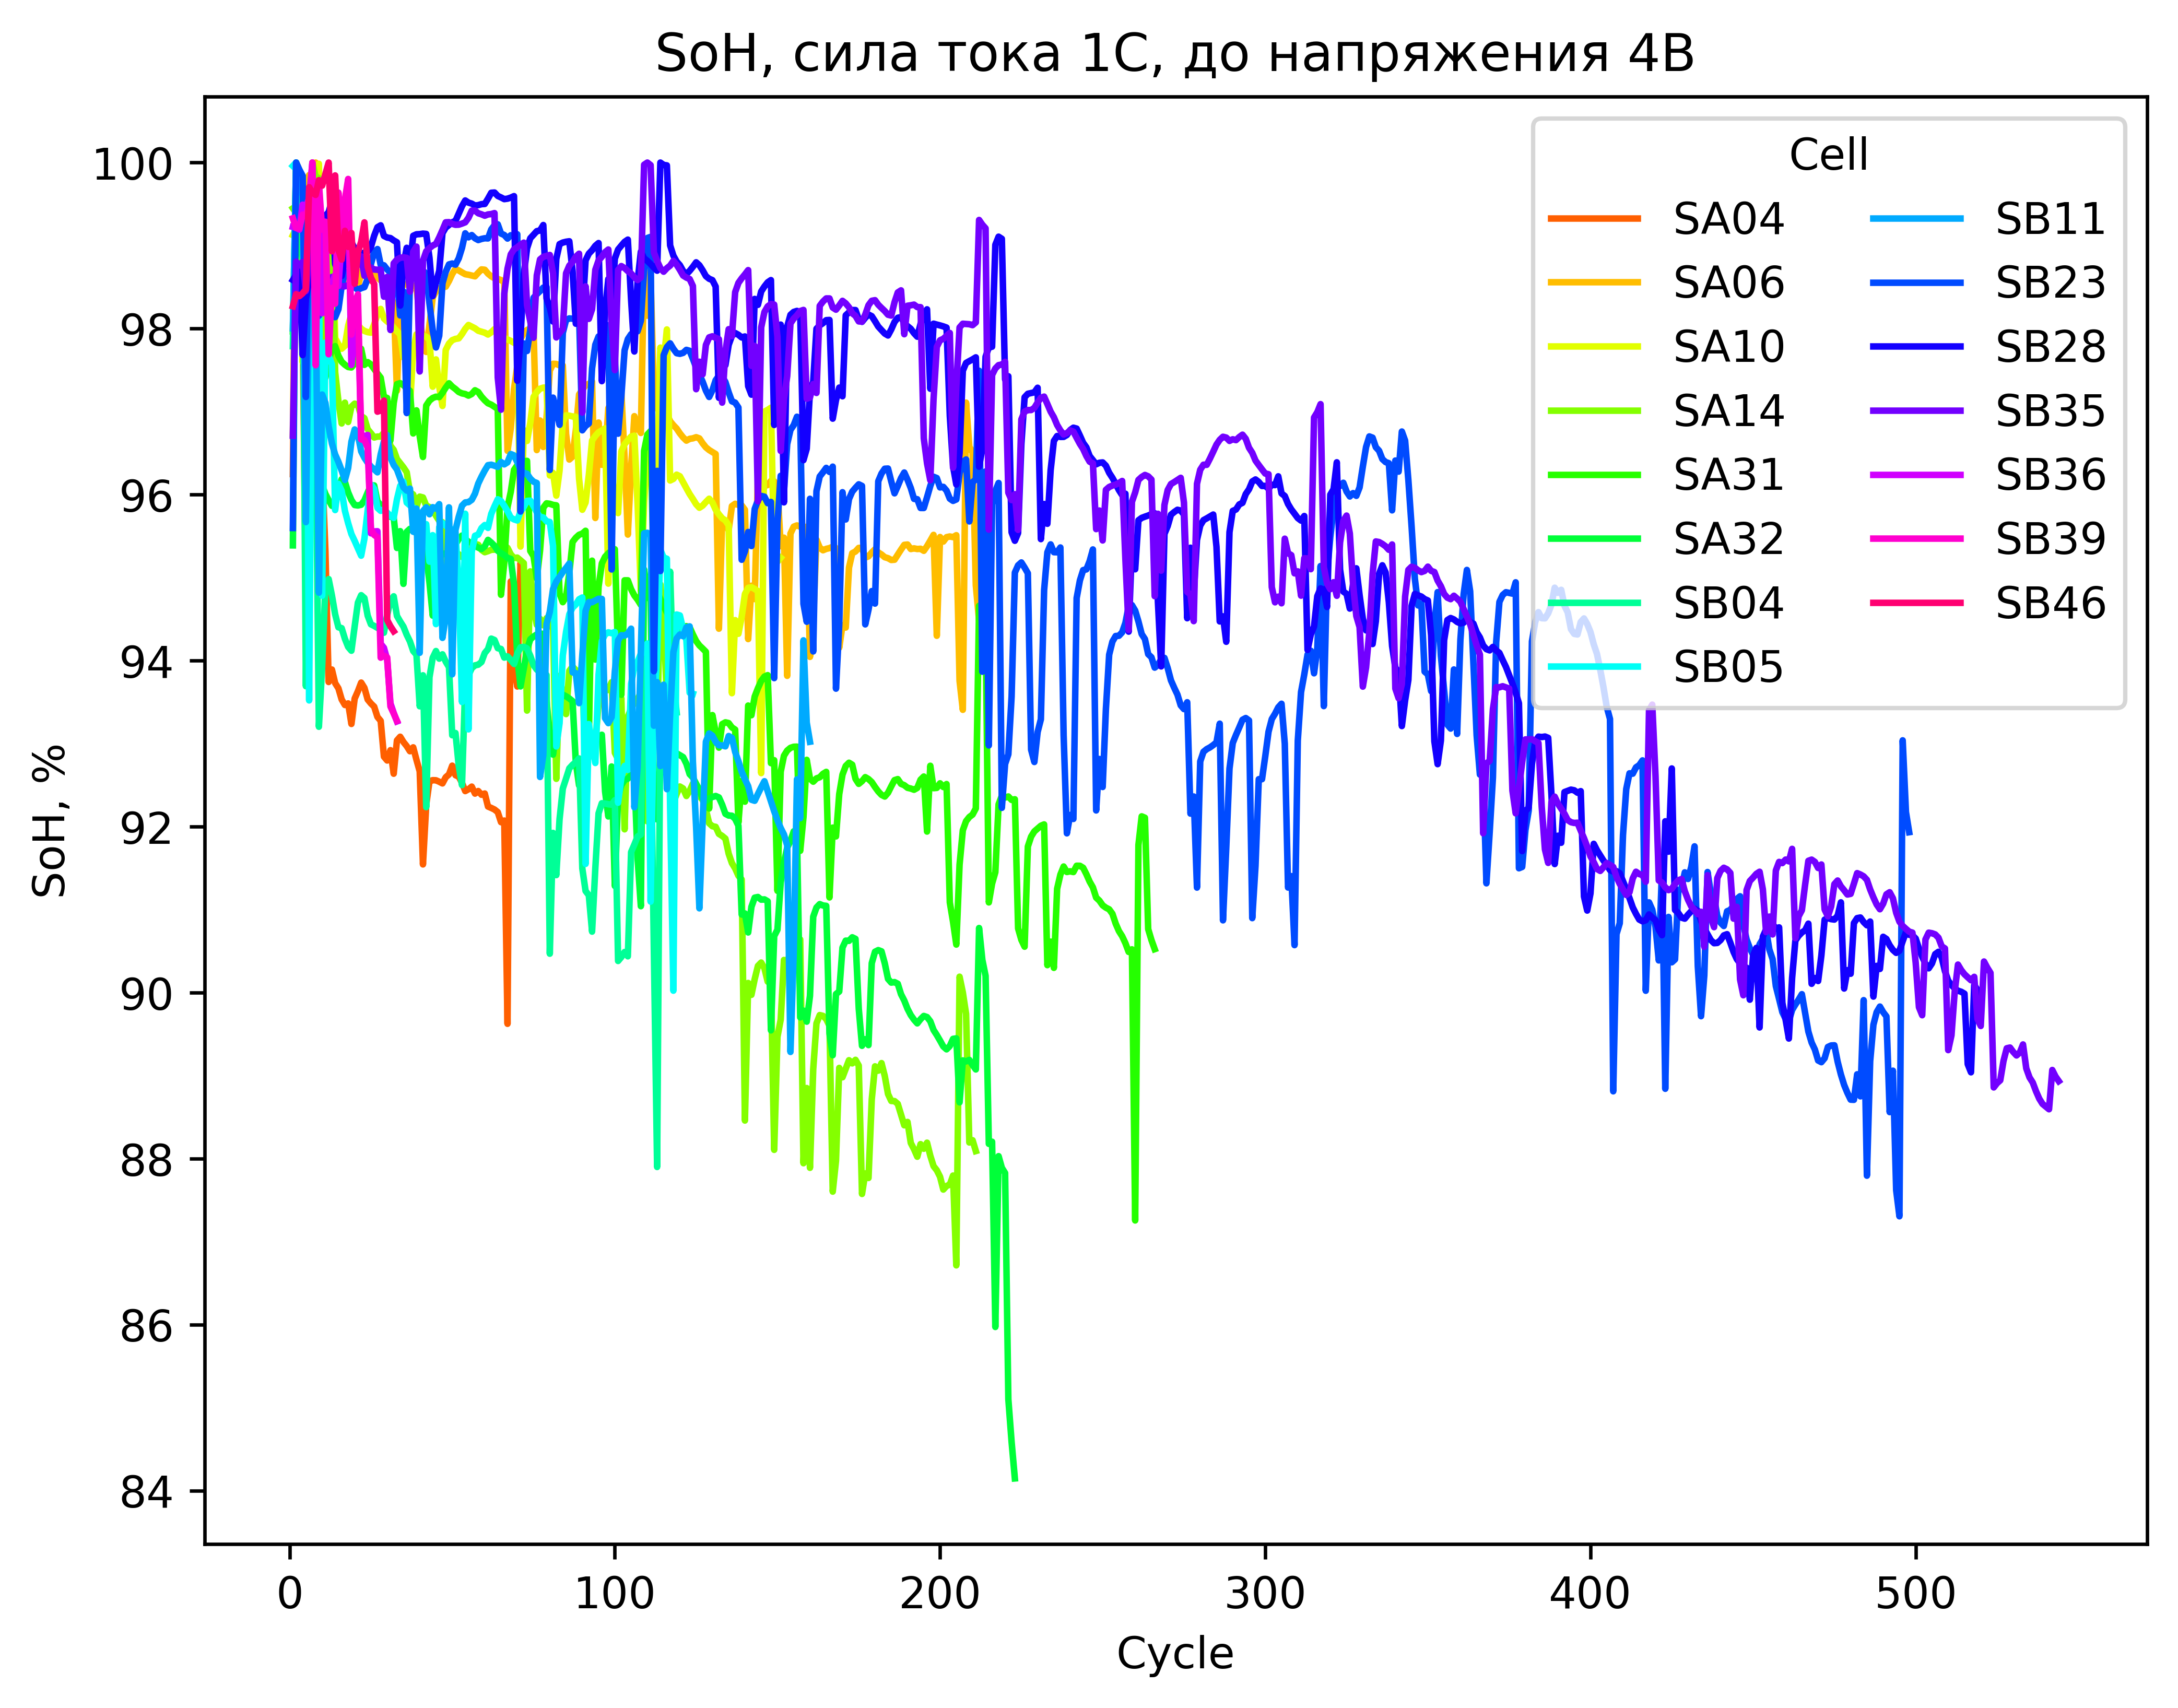

In [24]:
plt.figure(figsize=(8 ,6),dpi=600)
# sns.set_style("white")
plt.style.use('default')
voltage = 4
current = 1
# Group by the 'group' column
select_df = analysis_df[(analysis_df['test_type']==f'{voltage}V_cycle')&(analysis_df['DCh_C']==current)]
palette = sns.color_palette('hsv', n_colors=len(select_df.groupby('cell_code').filter(lambda x: len(x) > 30).groupby('cell_code')))
for i, (key, grp) in enumerate(select_df.groupby('cell_code').filter(lambda x: len(x) > 30).groupby('cell_code')):
    if key == 'SA43':
        continue
    x_vals = range(1, len(grp)+1)
    plt.plot(x_vals, grp['DCh_cap']/grp['DCh_cap'].max()*100, label=key, color=palette[i])

plt.xlabel('Cycle')
plt.ylabel('SoH, %')
plt.title(f'SoH, сила тока {current}С, до напряжения {voltage}В')
plt.legend(title='Cell',loc='best', ncol=2)
plt.show()

In [18]:
select_df[['Ch_curr','Ch_cap','DCh_cap', 'cell_code','timestamp']]

,Ch_curr,Ch_cap,DCh_cap,cell_code,timestamp
9432,649.981812,1195.976807,1190.083252,SB25,2024-08-27 03:54:20.665000+03:00
10080,650.015137,1240.512939,1235.156494,SB28,2024-08-27 05:38:01.565000+03:00
10216,649.982056,1239.164429,1234.109619,SA10,2024-08-27 06:08:42.165000+03:00
9829,649.995544,1253.435425,1247.877441,SB27,2024-08-27 06:33:04.365000+03:00
9275,649.987915,1257.848877,1253.247192,SB21,2024-08-27 06:38:31.465000+03:00
...,...,...,...,...,...
7414,3899.947510,1176.166260,1162.723022,SB39,2025-06-14 02:02:15.560000+03:00
7234,3899.902832,1158.191162,1157.687866,SB36,2025-06-14 02:33:25.860000+03:00
7415,3899.967041,1163.155640,1162.612549,SB39,2025-06-14 03:10:43.060000+03:00
7416,3899.958008,1162.913086,1162.281494,SB39,2025-06-14 04:18:58.060000+03:00


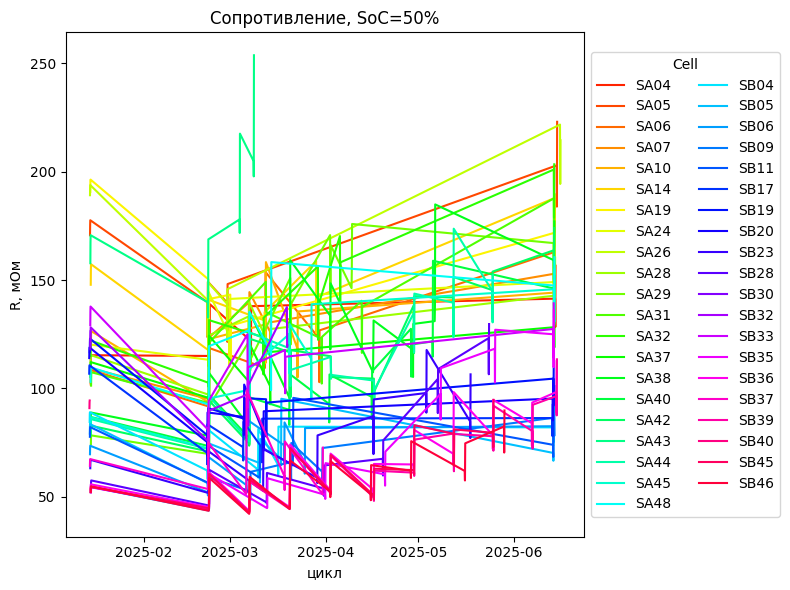

In [9]:
plt.figure(figsize=(8,6))
# sns.set_style("white")
plt.style.use('default')

# Group by the 'group' column
select_df = analysis_df[(analysis_df['test_type']==f'resistance')]
palette = sns.color_palette('hsv', n_colors=len(select_df.groupby('cell_code')))
for i, (key, grp) in enumerate(select_df.groupby('cell_code').filter(lambda x: len(x) > 0).groupby('cell_code')):
    x_vals = range(1, len(grp)+1)
    plt.plot(grp['timestamp'], grp['R']*1000, label=key, color=palette[i])

plt.xlabel('цикл')
plt.ylabel('R, мОм')
plt.title(f'Сопротивление, SoC=50%')
plt.legend(title='Cell',loc='center left', bbox_to_anchor=(1, 0.5), ncol=2)
#plt.xticks(rotation=45)  # поворот подписей на 45 градусов
plt.tight_layout()
plt.show()

<Axes: ylabel='Frequency'>

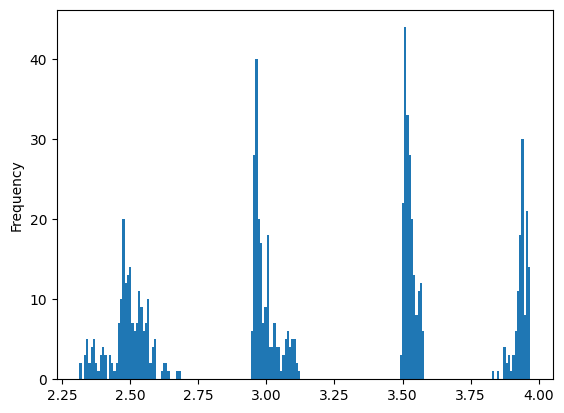

In [10]:
select_df['E0'].plot.hist(bins=200)